In [56]:
RESULTS_PATH = "../results/filter_scheduler"

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import json

In [58]:
with open(os.path.join(RESULTS_PATH, "config.json")) as file:
    config = json.load(file)
config

{'data_path': 'data',
 'model': 'efficientnet',
 'pre_trained': True,
 'output_shape': 128,
 'loss': 'triplet',
 'margin': 0.2,
 'optimizer': 'adam',
 'learning_rate': 0.0001,
 'scheduler': 'none',
 'epochs': 100,
 'patience': 100,
 'imgs_per_id': 2,
 'ids_per_batch': 32,
 'neg_porcent': 0.0,
 'train_batch': 64,
 'eval_batch': 64,
 'test_batch': 64,
 'device': 'cuda:0',
 'num_workers': 48,
 'semihard_eval': False,
 'hard_epoch': 101,
 'hard_filter': 'scheduler 10 50',
 'last_margin': 0.2}

# Loading DFs

In [59]:
df_metrics = pd.read_csv(os.path.join(RESULTS_PATH, "metrics.csv"))
df_metrics.head()

,epoch,train_loss,eval_loss,time,margin,val_auc,test_auc,test_acc,threshold,test_pos_dists,test_neg_dists,test_rand_index
0,1,0.186774,0.123428,90.511767,0.2,0.745473,0.787312,0.719,0.711293,0.675121,0.796952,0.000000
1,2,0.137478,0.102195,88.773972,0.2,0.783431,0.824392,0.732,0.648499,0.514548,0.975159,-0.000156
2,3,0.095273,0.073776,89.234214,0.2,0.845012,0.868844,0.785,0.713098,0.502088,1.050947,-0.000232
3,4,0.076844,0.064808,91.889302,0.2,0.857312,0.888704,0.817,0.735664,0.480183,1.108768,0.000678
4,5,0.061168,0.056195,89.581932,0.2,0.880914,0.899780,0.831,0.775585,0.489279,1.148196,0.000169


In [60]:
df_triplets = pd.read_csv(os.path.join(RESULTS_PATH, "triplets.csv"))
df_triplets.head()

,epoch,total,easy,semihard,superhard
0,1,226176,10647,114563,100966
1,2,230144,63431,95498,71215
2,3,230144,107701,75508,46935
3,4,230144,130919,61778,37447
4,5,226176,145871,51392,28913


# Best Epoch Results

In [61]:
best_epoch = int(df_metrics.iloc[df_metrics["eval_loss"].argmin()].epoch)
best_epoch

91

In [62]:
best_epoch_data = df_metrics[df_metrics["epoch"] == best_epoch]
best_epoch_data

,epoch,train_loss,eval_loss,time,margin,val_auc,test_auc,test_acc,threshold,test_pos_dists,test_neg_dists,test_rand_index
90,91,0.254273,0.019119,81.155217,0.2,0.960771,0.966432,0.903,0.718892,0.444274,1.151231,0.020551


# All Epochs Results

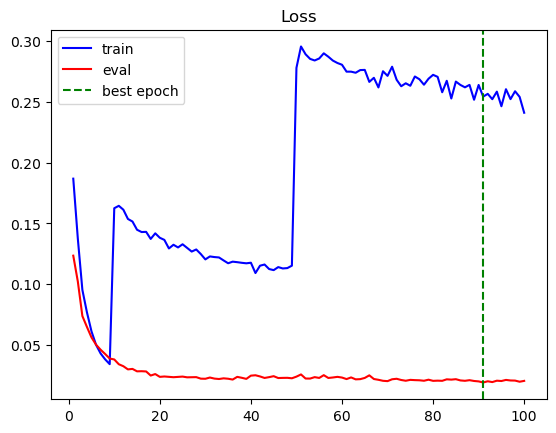

In [63]:
plt.plot(df_metrics["epoch"], df_metrics["train_loss"], color="blue", label="train")
plt.plot(df_metrics["epoch"], df_metrics["eval_loss"], color="red", label="eval")
plt.axvline(x=best_epoch, color="green", linestyle="--", label="best epoch")
plt.legend()
plt.title("Loss")
plt.show()

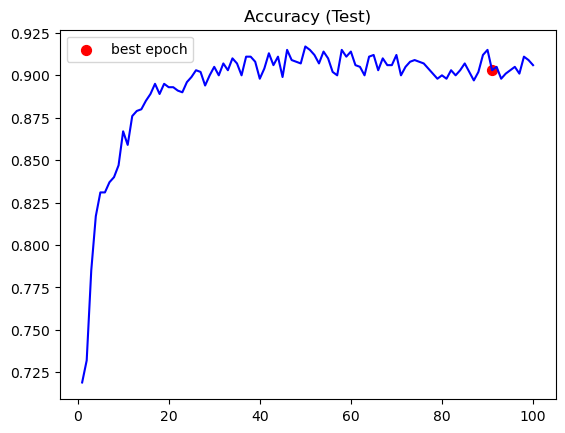

In [64]:
plt.scatter(best_epoch, best_epoch_data.test_acc, color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], df_metrics["test_acc"], color="blue")
plt.title("Accuracy (Test)")
plt.legend()
plt.show()

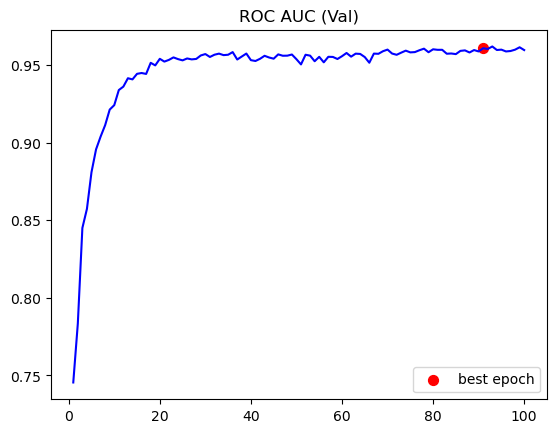

In [65]:
plt.scatter(best_epoch, best_epoch_data.val_auc, color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], df_metrics["val_auc"], color="blue")
plt.title("ROC AUC (Val)")
plt.legend()
plt.show()

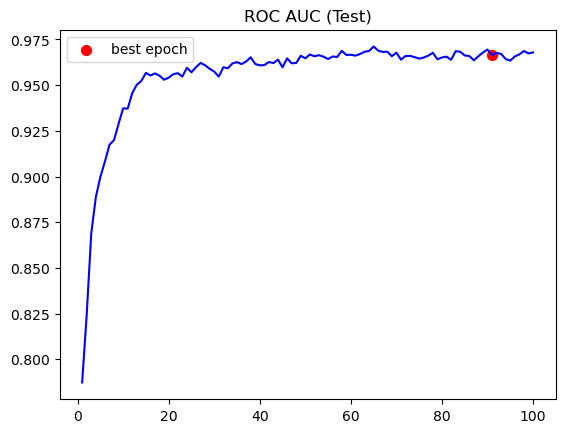

In [66]:
plt.scatter(best_epoch, best_epoch_data.test_auc, color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], df_metrics["test_auc"], color="blue")
plt.title("ROC AUC (Test)")
plt.legend()
plt.show()

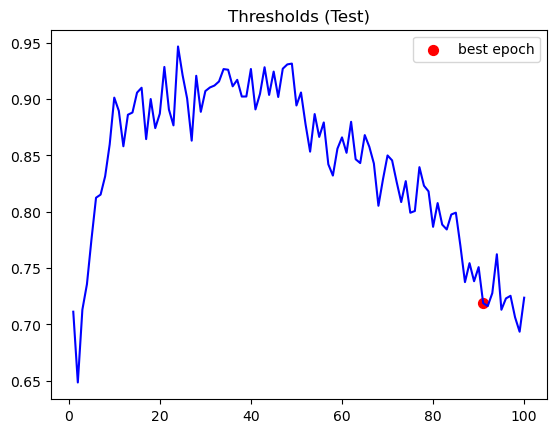

In [67]:
plt.scatter(best_epoch, best_epoch_data.threshold, color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], df_metrics["threshold"], color="blue")
plt.title("Thresholds (Test)")
plt.legend()
plt.show()

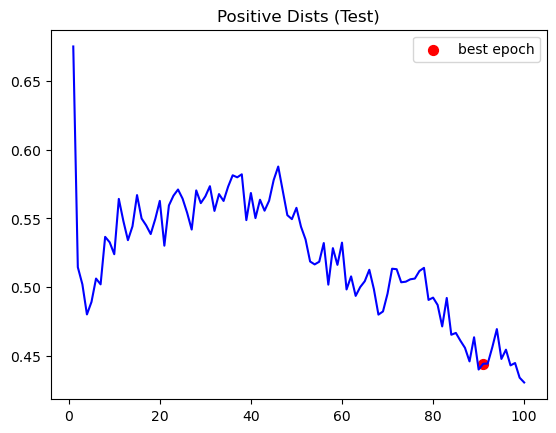

In [68]:
plt.scatter(best_epoch, best_epoch_data.test_pos_dists, color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], df_metrics["test_pos_dists"], color="blue")
plt.title("Positive Dists (Test)")
plt.legend()
plt.show()

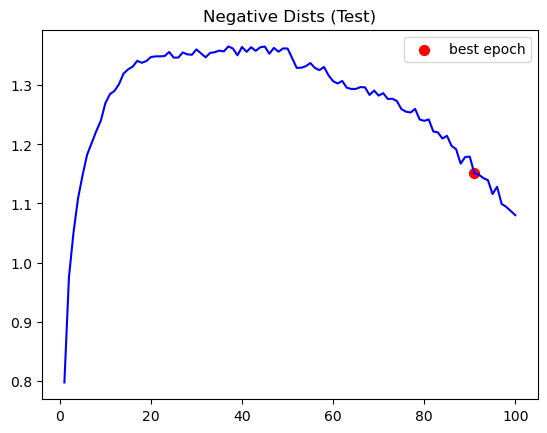

In [69]:
plt.scatter(best_epoch, best_epoch_data.test_neg_dists, color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], df_metrics["test_neg_dists"], color="blue")
plt.title("Negative Dists (Test)")
plt.legend()
plt.show()

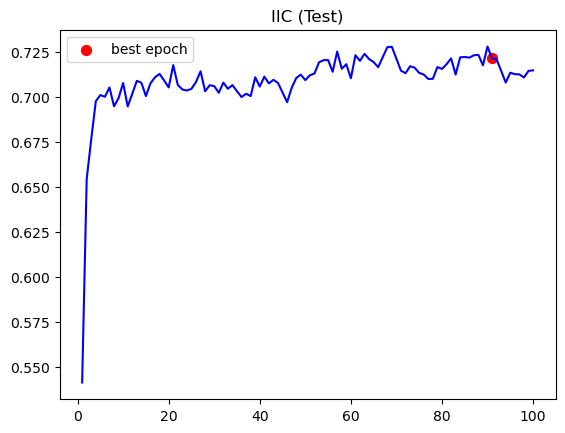

In [70]:
test_iic = df_metrics["test_neg_dists"] / (df_metrics["test_neg_dists"] + df_metrics["test_pos_dists"])
plt.scatter(best_epoch, test_iic.iloc[best_epoch_data.index], color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], test_iic, color="blue")
plt.title("IIC (Test)")
plt.legend()
plt.show()

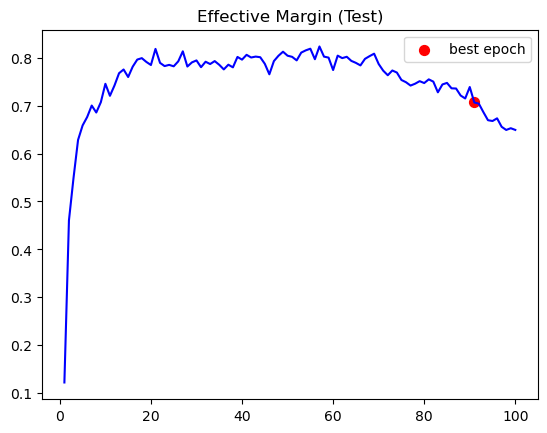

In [71]:
eff_margin = df_metrics["test_neg_dists"] - df_metrics["test_pos_dists"]
plt.scatter(best_epoch, eff_margin.iloc[best_epoch_data.index], color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], eff_margin, color="blue")
plt.title("Effective Margin (Test)")
plt.legend()
plt.show()

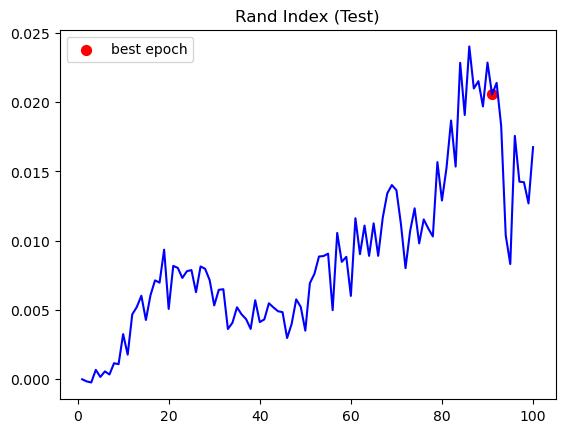

In [72]:
plt.scatter(best_epoch, best_epoch_data.test_rand_index, color="red", marker="o", s=50, 
            label="best epoch")
plt.plot(df_metrics["epoch"], df_metrics["test_rand_index"], color="blue")
plt.title("Rand Index (Test)")
plt.legend()
plt.show()

# Distance Histograms

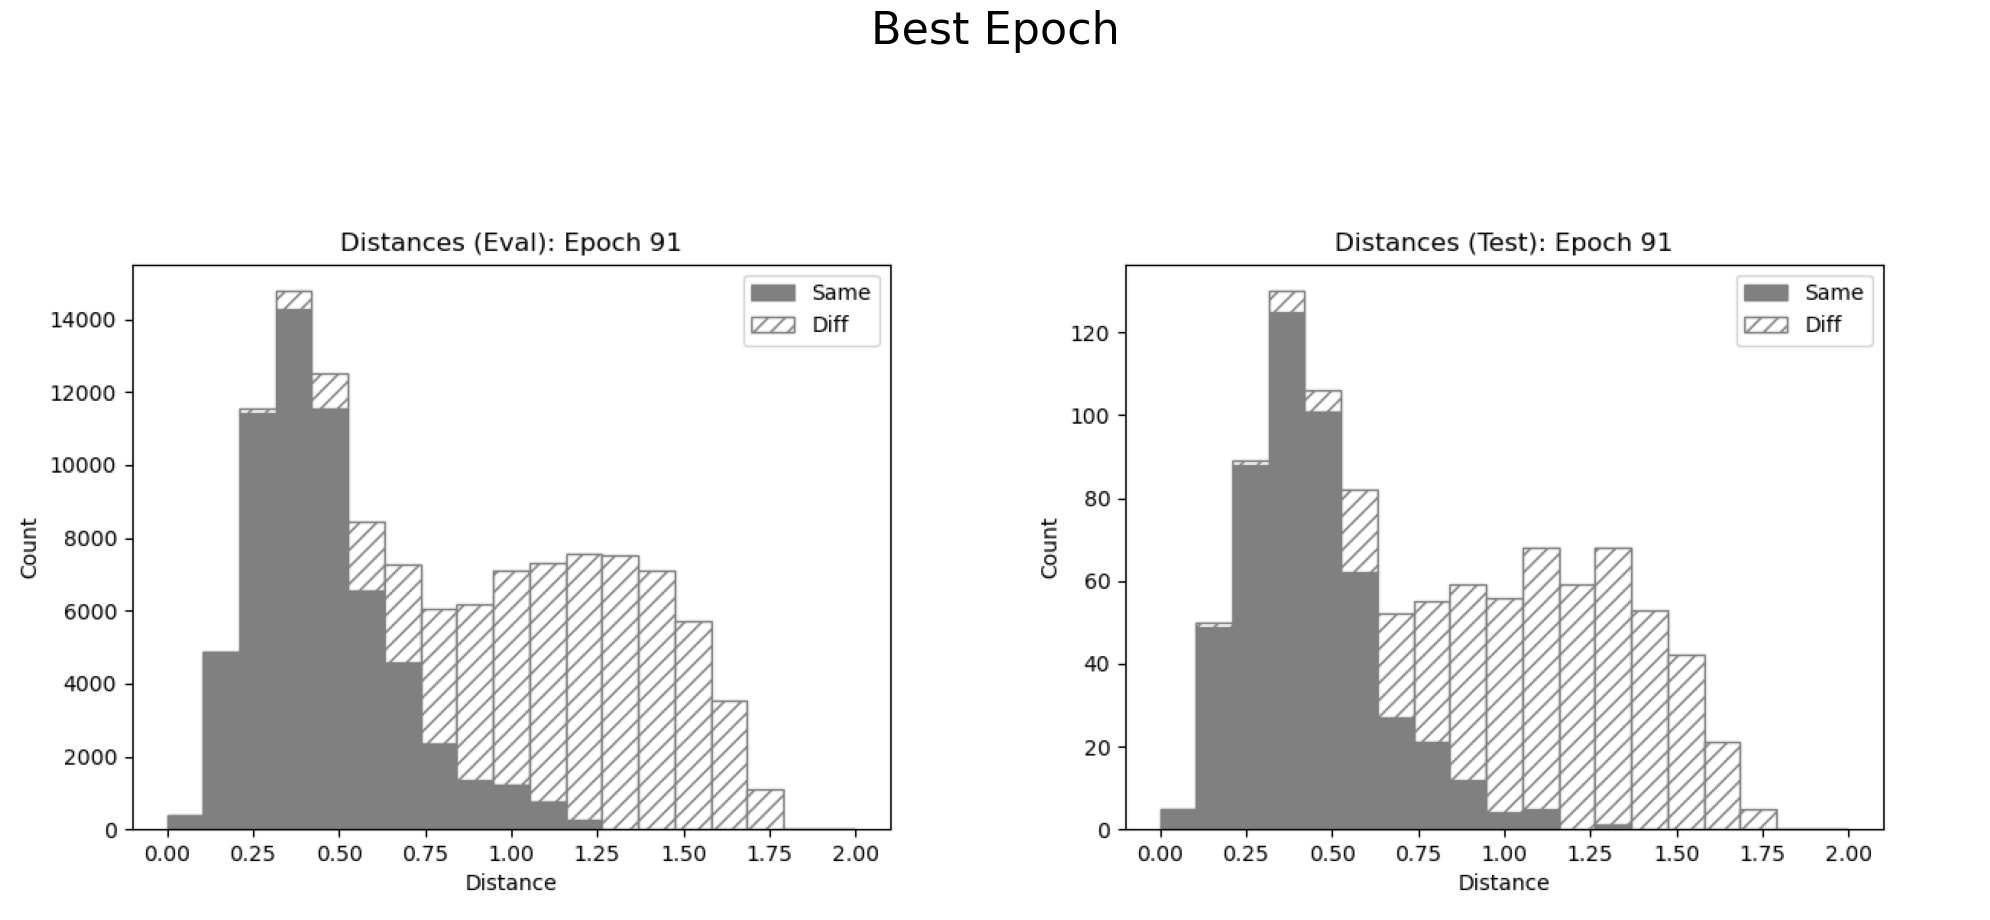

In [73]:
# compare distances histogram in eval (best epoch) and test
img2 = mpimg.imread(os.path.join(RESULTS_PATH, "distances", "test", f"epoch{best_epoch}.png"))
img1 = mpimg.imread(os.path.join(RESULTS_PATH, "distances", "eval", f"epoch{best_epoch}.png"))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(img1)
axes[0].axis("off")
axes[1].imshow(img2)
axes[1].axis("off")

fig.suptitle("Best Epoch", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # reserve top 5% for title
plt.show()

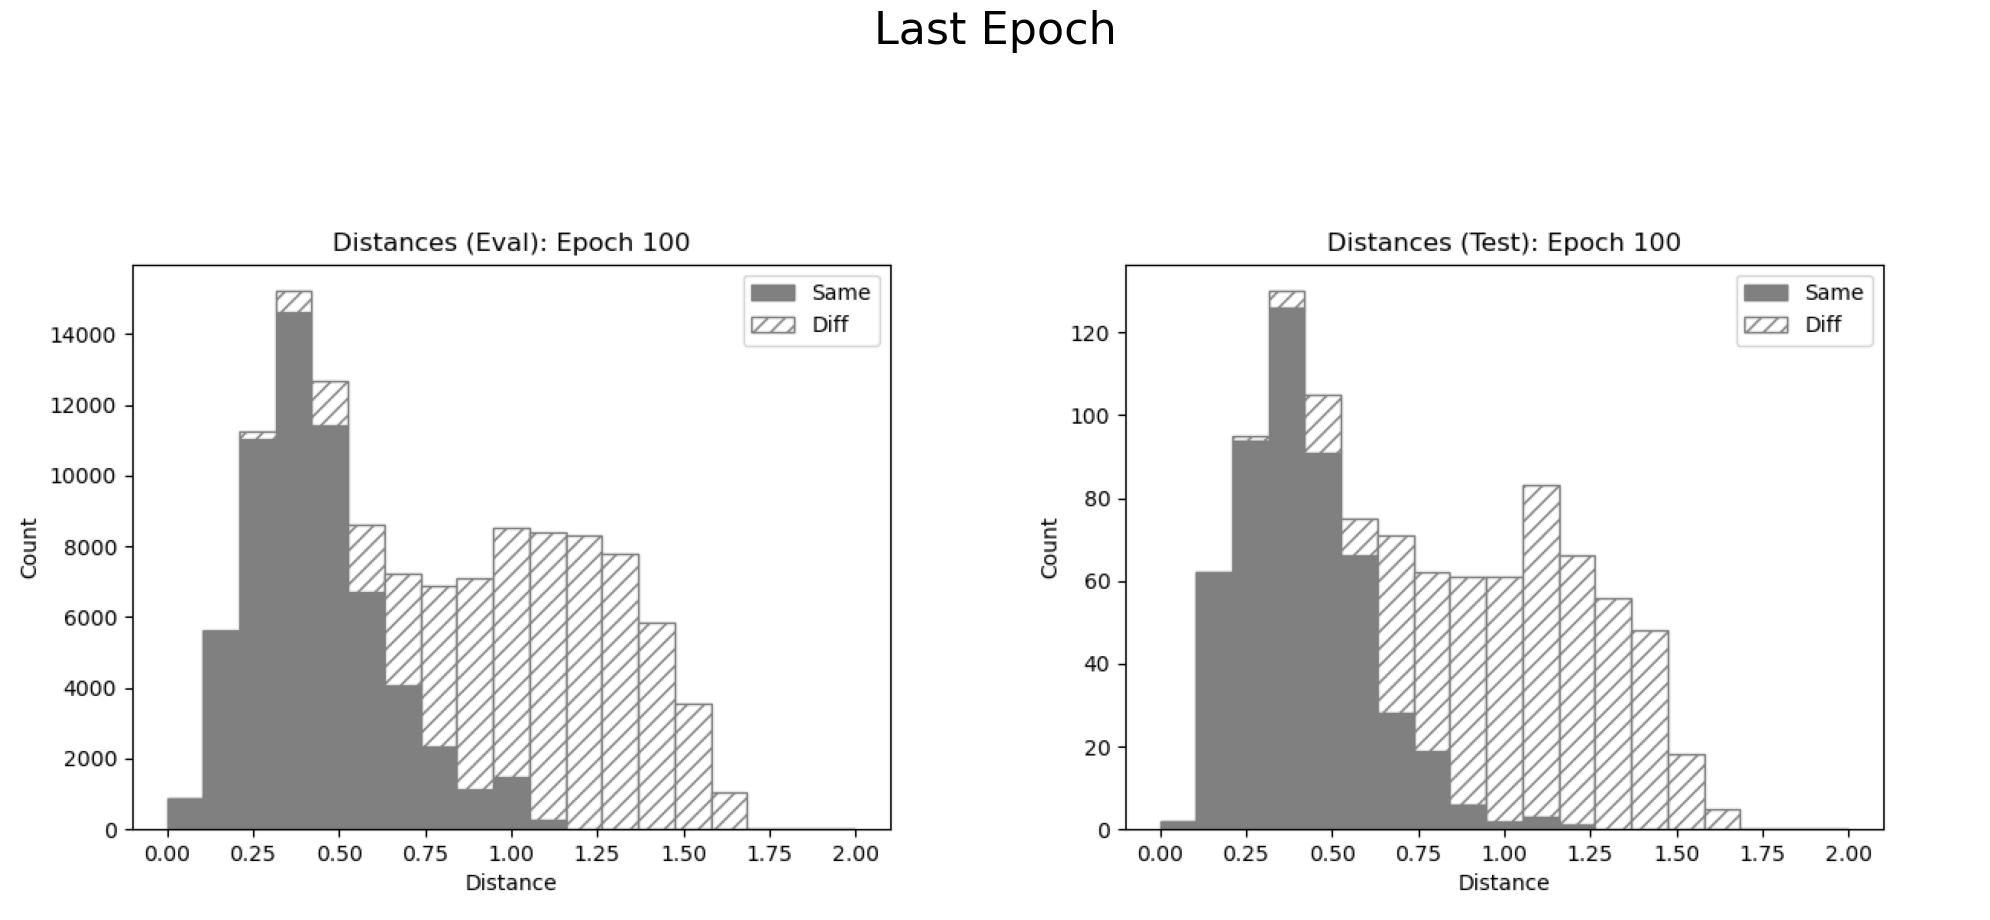

In [74]:
# compare distances histogram in eval and test (last epoch)
last_epoch = df_metrics["epoch"].max()
img2 = mpimg.imread(os.path.join(RESULTS_PATH, "distances", "test", f"epoch{last_epoch}.png"))
img1 = mpimg.imread(os.path.join(RESULTS_PATH, "distances", "eval", f"epoch{last_epoch}.png"))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(img1)
axes[0].axis("off")
axes[1].imshow(img2)
axes[1].axis("off")

fig.suptitle("Last Epoch", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # reserve top 5% for title
plt.show()

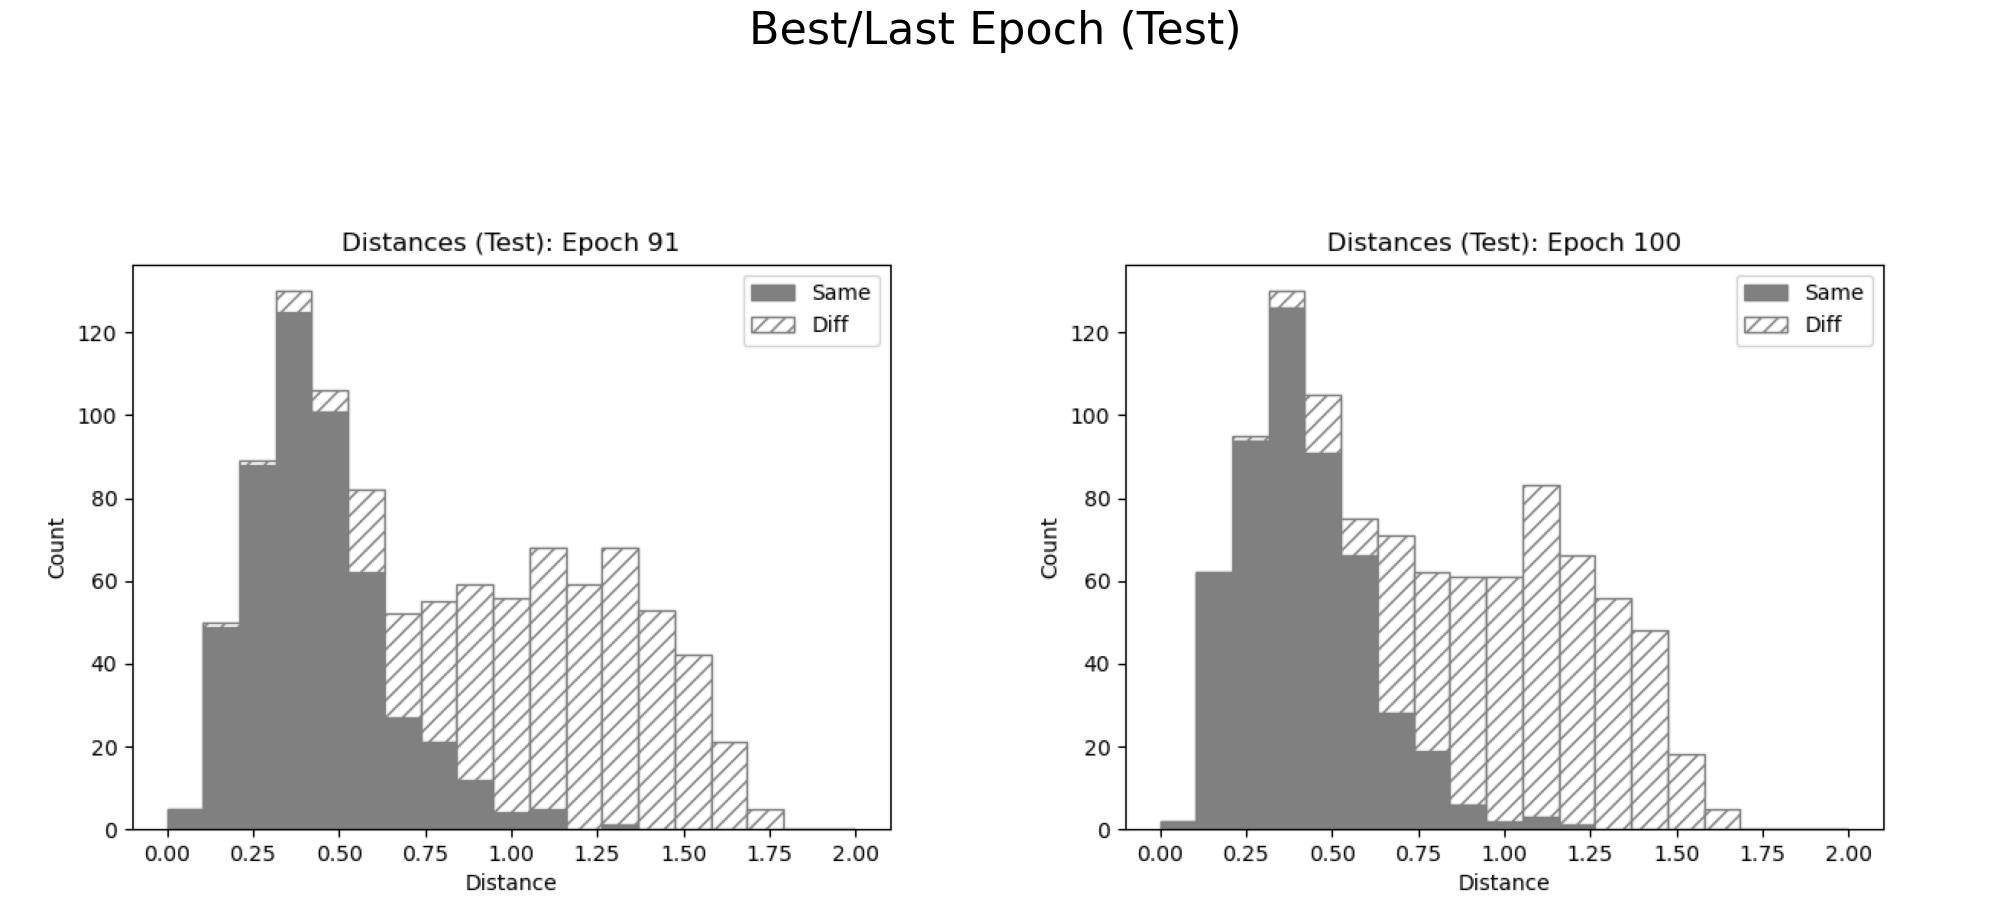

In [75]:
# comparing test results in best and last epochs
img2 = mpimg.imread(os.path.join(RESULTS_PATH, "distances", "test", f"epoch{last_epoch}.png"))
img1 = mpimg.imread(os.path.join(RESULTS_PATH, "distances", "test", f"epoch{best_epoch}.png"))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(img1)
axes[0].axis("off")
axes[1].imshow(img2)
axes[1].axis("off")

fig.suptitle("Best/Last Epoch (Test)", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # reserve top 5% for title
plt.show()

In [76]:
df_metrics[df_metrics["epoch"].isin([best_epoch, last_epoch])]

,epoch,train_loss,eval_loss,time,margin,val_auc,test_auc,test_acc,threshold,test_pos_dists,test_neg_dists,test_rand_index
90,91,0.254273,0.019119,81.155217,0.2,0.960771,0.966432,0.903,0.718892,0.444274,1.151231,0.020551
99,100,0.240991,0.020435,80.433539,0.2,0.959609,0.967856,0.906,0.723730,0.430676,1.080231,0.016752


## Number of Triplets

<Axes: xlabel='epoch', ylabel='total'>

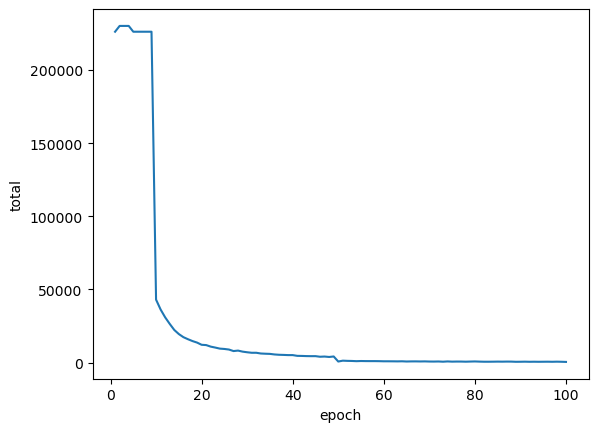

In [77]:
sns.lineplot(data=df_triplets, x="epoch", y="total")

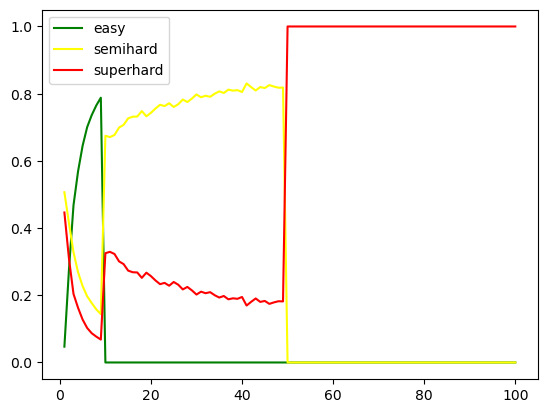

In [78]:
df_triplets["easy_porcent"] = df_triplets["easy"] / df_triplets["total"]
df_triplets["semihard_porcent"] = df_triplets["semihard"] / df_triplets["total"]
df_triplets["superhard_porcent"] = df_triplets["superhard"] / df_triplets["total"]

plt.plot(df_triplets["epoch"], df_triplets["easy_porcent"], label="easy", color="green")
plt.plot(df_triplets["epoch"], df_triplets["semihard_porcent"], label="semihard", color="yellow")
plt.plot(df_triplets["epoch"], df_triplets["superhard_porcent"], label="superhard", color="red")
plt.legend()

plt.show()

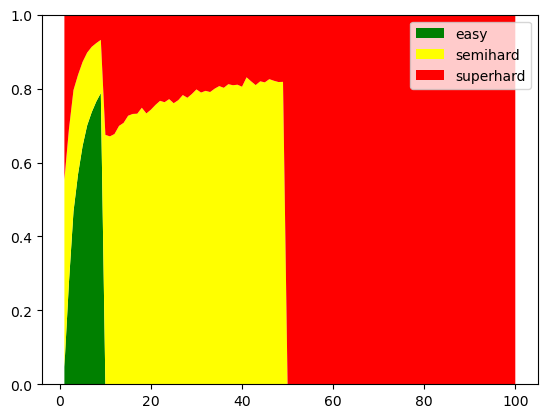

In [79]:
plt.stackplot(df_triplets["epoch"], df_triplets["easy_porcent"], df_triplets["semihard_porcent"], 
              df_triplets["superhard_porcent"], labels=["easy", "semihard", "superhard"], colors=["green", "yellow", "red"])
plt.legend()
plt.ylim(0, 1)
plt.show()

In [80]:
df_triplets.tail(10)

,epoch,total,easy,semihard,superhard,easy_porcent,semihard_porcent,superhard_porcent
90,91,618,0,0,618,0.0,0.0,1.0
91,92,540,0,0,540,0.0,0.0,1.0
92,93,584,0,0,584,0.0,0.0,1.0
93,94,538,0,0,538,0.0,0.0,1.0
94,95,569,0,0,569,0.0,0.0,1.0
95,96,595,0,0,595,0.0,0.0,1.0
96,97,542,0,0,542,0.0,0.0,1.0
97,98,618,0,0,618,0.0,0.0,1.0
98,99,547,0,0,547,0.0,0.0,1.0
99,100,445,0,0,445,0.0,0.0,1.0


In [81]:
df_triplets.head(10)

,epoch,total,easy,semihard,superhard,easy_porcent,semihard_porcent,superhard_porcent
0,1,226176,10647,114563,100966,0.047074,0.506521,0.446405
1,2,230144,63431,95498,71215,0.275614,0.414949,0.309437
2,3,230144,107701,75508,46935,0.467972,0.328090,0.203938
3,4,230144,130919,61778,37447,0.568857,0.268432,0.162711
4,5,226176,145871,51392,28913,0.644945,0.227221,0.127834
5,6,226176,158418,44533,23225,0.700419,0.196895,0.102686
6,7,226176,166511,39981,19684,0.736201,0.176769,0.087030
7,8,226176,173008,35763,17405,0.764926,0.158120,0.076953
8,9,226176,178228,32529,15419,0.788006,0.143822,0.068173
9,10,43037,0,29040,13997,0.000000,0.674768,0.325232
